# Parte 1-Comparación de TF-IDF de palabras y caracteres

### Relación con el trabajo inicial

Este notebook complementa la primera implementación del grupo mediante una
comparación entre TF-IDF de palabras y TF-IDF de caracteres, utilizando
regresión logística de scikit-learn.

## 1. Imports y configuración 

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
LABELS = ["negativo", "neutral", "positivo"]

# Localizar la raíz del proyecto.
ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"

assert (DATA_DIR / "train.csv").exists(), \
    "No se encuentra data/train.csv."

print("Carpeta de datos:", DATA_DIR)
print("Configuración lista.")

Carpeta de datos: /Users/alejandrobenavidesrubio/MLP1/data
Configuración lista.


## 2. Carga de datos

In [4]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train_df.shape)
print("eval:", eval_df.shape)
print("sample_submission:", sample_submission.shape)
train_df.head()

train: (12000, 3)
eval: (3000, 2)
sample_submission: (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


### 2.1 Consistencia de los datos

Revisamos las etiquetas, los valores nulos, los textos duplicados y la
distribución de clases antes de entrenar los modelos.

In [5]:
assert set(train_df["label"].unique()) == set(LABELS)

print("Valores nulos en train:\n", train_df.isna().sum())
print("\nValores nulos en eval:\n", eval_df.isna().sum())

print("\nReseñas duplicadas en train:",
      train_df["text"].duplicated().sum())

print("\nCantidad de reseñas por clase:")
print(train_df["label"].value_counts())

Valores nulos en train:
 id       0
text     0
label    0
dtype: int64

Valores nulos en eval:
 id      0
text    0
dtype: int64

Reseñas duplicadas en train: 0

Cantidad de reseñas por clase:
label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64


## 3. Preprocesamiento y separación de datos

Aplicamos la misma limpieza del notebook inicial: convertimos a minúsculas,
eliminamos URLs y ciertos símbolos, y normalizamos espacios. Conservamos
tildes y palabras de negación como “no”, “nunca” y “sin”.

Reservamos el 15 % de los datos etiquetados para validación, manteniendo
la proporción de clases mediante estratificación y utilizando la semilla 42.
Todos los modelos utilizarán exactamente esta misma separación.

In [6]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿñÑ0-9¡!¿?.,;: ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


train_df["text_clean"] = train_df["text"].apply(clean_text)
eval_df["text_clean"] = eval_df["text"].apply(clean_text)

train_df[["text", "text_clean"]].head(3)

,text,text_clean
0,Lo pedí un martes por la noche y me llegó al d...,lo pedí un martes por la noche y me llegó al d...
1,Se lo compré a un familiar después de pensarla...,se lo compré a un familiar después de pensarla...
2,Lo pedí a mediados de mes y me llegó en tres d...,lo pedí a mediados de mes y me llegó en tres d...


In [7]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df["text_clean"],
    train_df["label"],
    test_size=0.15,
    stratify=train_df["label"],
    random_state=RANDOM_STATE,
)

print("Entrenamiento:", len(X_train_text))
print("Validación:", len(X_val_text))

print("\nProporción de clases:")
pd.DataFrame({
    "entrenamiento": y_train.value_counts(normalize=True),
    "validacion": y_val.value_counts(normalize=True),
}).round(3)

Entrenamiento: 10200
Validación: 1800

Proporción de clases:


,entrenamiento,validacion
label,,
negativo,0.351,0.351
neutral,0.298,0.298
positivo,0.351,0.351


## 4. Reproducción del modelo base

Entrenamos la configuración seleccionada en el notebook inicial:
TF-IDF de unigramas y bigramas con regresión logística.

Su resultado en esta misma validación será la referencia para evaluar
el experimento con caracteres.

Accuracy del modelo base: 0.7339

              precision    recall  f1-score   support

    negativo      0.632     0.609     0.620       632
     neutral      0.969     0.998     0.983       536
    positivo      0.628     0.634     0.631       632

    accuracy                          0.734      1800
   macro avg      0.743     0.747     0.745      1800
weighted avg      0.731     0.734     0.732      1800



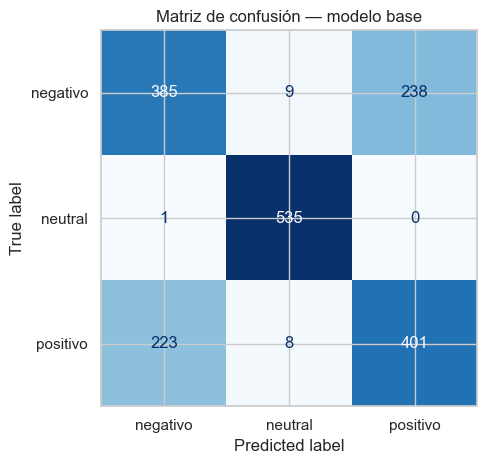

In [8]:
baseline_pipe = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

baseline_pipe.fit(X_train_text, y_train)
baseline_preds = baseline_pipe.predict(X_val_text)
baseline_acc = accuracy_score(y_val, baseline_preds)

print(f"Accuracy del modelo base: {baseline_acc:.4f}")
print()
print(classification_report(
    y_val,
    baseline_preds,
    labels=LABELS,
    digits=3,
))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    baseline_preds,
    labels=LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Matriz de confusión — modelo base")
plt.tight_layout()
plt.show()

## 5. Análisis de errores del modelo base

El modelo obtuvo un accuracy de 0,7339 en validación. De los 479 errores,
461 (96,2 %) corresponden a confusiones entre las clases positiva y negativa.
La clase neutral presenta 535 aciertos de 536 ejemplos.

Revisaremos textos completos mal clasificados para identificar posibles
dificultades relacionadas con negaciones, opiniones mixtas y conectores
contrastivos. Estas causas son hipótesis que debemos contrastar con los ejemplos.

In [9]:
val_df = train_df.loc[
    X_val_text.index, ["id", "text", "label"]
].copy()

val_df = val_df.rename(columns={"label": "real"})
val_df["pred"] = baseline_preds

errores = val_df[val_df["real"] != val_df["pred"]].copy()

print(f"Errores totales: {len(errores)} de {len(val_df)}")

for real, pred in [
    ("negativo", "positivo"),
    ("positivo", "negativo"),
]:
    casos = errores[
        (errores["real"] == real) & (errores["pred"] == pred)
    ]

    print(f"\n=== Real: {real} → Predicción: {pred} ===")

    muestra = casos.sample(
        n=min(3, len(casos)),
        random_state=RANDOM_STATE,
    )

    for _, fila in muestra.iterrows():
        print(f"\nID: {fila['id']}")
        print(fila["text"])

Errores totales: 479 de 1800

=== Real: negativo → Predicción: positivo ===

ID: 1918
Compre esto a mediados de mes y llego en cuatro dias a mi casa. El manual de uso funciona bastante mal, la verdad me costo entender varias partes. Eso si, quede encantado con la app del fabricante, la estuve probando desde el primer dia. Todavia no me decido.

ID: 20
Compré esta correa para mi perro hace unas tres semanas, la pedí un martes y me llegó el jueves siguiente. La verdad, la correa me pareció mal terminada desde el primer día. La uso todas las tardes cuando salimos a caminar por el parque cerca de mi casa.

ID: 7824
Compre esta funda la semana pasada para el telefono que me regalaron en diciembre, llego en tres dias y el color era igual al de la foto. En mi opinion, la funda resulto redonda comparado con otros. La uso a diario para ir al trabajo y llevo el celular en el bolsillo del pantalon. A fin de cuentas, el material me resulto decepcionante en estas semanas.

=== Real: positivo → Pred

### 5.1 Observaciones de la muestra

Se revisaron seis errores, seleccionando tres de cada dirección de confusión
entre positivo y negativo. Varios contienen valoraciones opuestas sobre
distintos aspectos del producto; también aparecen expresiones negativas
claras que el modelo no clasificó correctamente.

Algunos textos resultan ambiguos o contradictorios. Esta muestra permite
formular hipótesis, pero no demuestra que las etiquetas sean incorrectas
ni que todos los errores tengan la misma causa.

## 6. Experimento con TF-IDF de caracteres

Evaluamos fragmentos de 3 a 5 caracteres dentro de los límites de las palabras
mediante `analyzer="char_wb"`. Esta representación podría ayudar con variantes
ortográficas y fragmentos compartidos entre palabras.

Conservamos la limpieza, el split y la configuración de regresión logística
del modelo base. El cambio principal es la representación del texto.

Accuracy del modelo base:       0.7339
Accuracy del modelo caracteres: 0.7328
Diferencia: -0.11 puntos porcentuales

              precision    recall  f1-score   support

    negativo      0.636     0.592     0.613       632
     neutral      0.964     0.998     0.981       536
    positivo      0.624     0.649     0.636       632

    accuracy                          0.733      1800
   macro avg      0.741     0.746     0.743      1800
weighted avg      0.729     0.733     0.731      1800



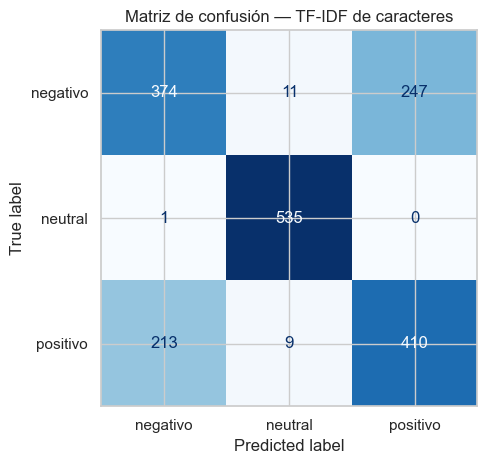

In [10]:
char_pipe = Pipeline([
    ("vec", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

char_pipe.fit(X_train_text, y_train)
char_preds = char_pipe.predict(X_val_text)
char_acc = accuracy_score(y_val, char_preds)

print(f"Accuracy del modelo base:       {baseline_acc:.4f}")
print(f"Accuracy del modelo caracteres: {char_acc:.4f}")
print(f"Diferencia: {(char_acc - baseline_acc) * 100:+.2f} puntos porcentuales")

print()
print(classification_report(
    y_val,
    char_preds,
    labels=LABELS,
    digits=3,
))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    char_preds,
    labels=LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Matriz de confusión — TF-IDF de caracteres")
plt.tight_layout()
plt.show()

### 6.1 Resultado del experimento

La representación TF-IDF de caracteres obtuvo un accuracy de 0,7328,
frente a 0,7339 del modelo de palabras. Esto equivale a dos aciertos menos
en los 1.800 ejemplos de validación.

Los aciertos de la clase positiva aumentaron de 401 a 410, mientras que
los de la clase negativa disminuyeron de 385 a 374. Los aciertos neutrales
se mantuvieron en 535.

En esta configuración y separación de datos, sustituir palabras por
caracteres no mejoró el accuracy. Conservamos el modelo de palabras como
referencia; no generalizamos esta conclusión a otras configuraciones.

In [11]:
base_correcto = baseline_preds == y_val.to_numpy()
char_correcto = char_preds == y_val.to_numpy()

print("Ambos aciertan:", (base_correcto & char_correcto).sum())
print("Solo palabras acierta:", (base_correcto & ~char_correcto).sum())
print("Solo caracteres acierta:", (~base_correcto & char_correcto).sum())
print("Ambos fallan:", (~base_correcto & ~char_correcto).sum())

Ambos aciertan: 1190
Solo palabras acierta: 131
Solo caracteres acierta: 129
Ambos fallan: 350


### 6.2 Combinación de palabras y caracteres

Los modelos aciertan simultáneamente 1.190 reseñas y fallan simultáneamente
350. El modelo de palabras acierta 131 ejemplos que el de caracteres falla;
el de caracteres acierta 129 que el de palabras falla.

Estos resultados motivan un experimento que combina ambas representaciones
mediante `FeatureUnion`, seguido de una regresión logística. Conservamos
la misma separación de datos y evaluamos si la combinación mejora el accuracy.

                      modelo  accuracy_val
TF-IDF palabras + caracteres      0.741111
             TF-IDF palabras      0.733889
           TF-IDF caracteres      0.732778

Diferencia frente al baseline: +0.72 puntos porcentuales


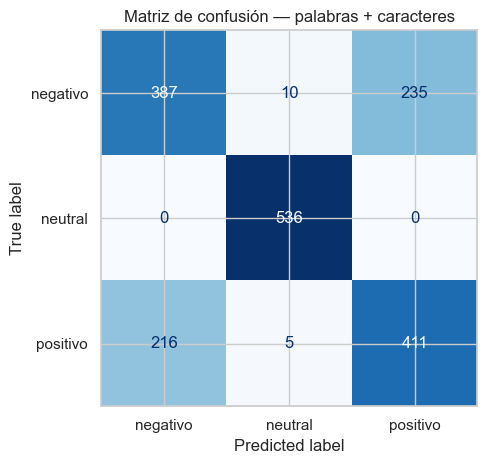

In [12]:
from sklearn.pipeline import FeatureUnion

combined_pipe = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
        )),
    ])),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

combined_pipe.fit(X_train_text, y_train)
combined_preds = combined_pipe.predict(X_val_text)
combined_acc = accuracy_score(y_val, combined_preds)

results_df = pd.DataFrame([
    {"modelo": "TF-IDF palabras", "accuracy_val": baseline_acc},
    {"modelo": "TF-IDF caracteres", "accuracy_val": char_acc},
    {"modelo": "TF-IDF palabras + caracteres",
     "accuracy_val": combined_acc},
]).sort_values("accuracy_val", ascending=False)

print(results_df.to_string(index=False))
print(
    f"\nDiferencia frente al baseline: "
    f"{(combined_acc - baseline_acc) * 100:+.2f} puntos porcentuales"
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    combined_preds,
    labels=LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Matriz de confusión — palabras + caracteres")
plt.tight_layout()
plt.show()

## 7. Comparación de resultados y conclusiones

Se compararon tres representaciones utilizando la misma limpieza de texto,
la misma separación estratificada de entrenamiento y validación y la misma
configuración de regresión logística.

| Representación | Accuracy de validación |
|---|---:|
| TF-IDF de palabras — baseline | 0,7339 |
| TF-IDF de caracteres | 0,7328 |
| TF-IDF de palabras + caracteres | **0,7411** |

Usar únicamente caracteres no superó al baseline. Sin embargo, ambos modelos
acertaban ejemplos diferentes, lo que motivó combinar sus representaciones
mediante `FeatureUnion`.

La combinación obtuvo 13 aciertos adicionales y redujo los errores de 479
a 466, una mejora de 0,72 puntos porcentuales frente al baseline.
La confusión entre positivo y negativo sigue siendo la dificultad principal.

Estos resultados son exploratorios: se utilizó una única partición de
validación para comparar y orientar los experimentos. El siguiente paso
es comprobar la estabilidad de la mejora mediante validación cruzada y
evaluar el candidato en Kaggle.

### Aporte de este experimento

- Reproducción del resultado del modelo base.
- Análisis de la matriz de confusión y revisión de seis errores.
- Evaluación de TF-IDF de caracteres.
- Evaluación de la combinación de palabras y caracteres.
- Documentación de resultados y limitaciones.

## 8. Entrenamiento final y generación del submission

Reentrenamos la configuración de palabras + caracteres con todos los datos
etiquetados de `train.csv`. Después generamos las predicciones para `eval.csv`.

El accuracy de 0,7411 corresponde al experimento anterior de validación;
el desempeño en Kaggle se conocerá después del envío.

Guardamos el modelo experimental y su submission con nombres independientes.
El modelo guardado incluye la limpieza de texto para recibir reseñas originales.

In [13]:
import joblib
from sklearn.base import clone
from sklearn.preprocessing import FunctionTransformer

def clean_text_batch(texts):
    return [clean_text(text) for text in texts]

# clone conserva la configuración, pero elimina el entrenamiento anterior.
final_pipe = Pipeline([
    ("clean", FunctionTransformer(clean_text_batch, validate=False)),
    ("model", clone(combined_pipe)),
])

final_pipe.fit(train_df["text"], train_df["label"])

eval_preds = final_pipe.predict(eval_df["text"])

print("Entrenamiento final completado.")
print("Reseñas utilizadas:", len(train_df))
print("\nPredicciones por clase:")
print(pd.Series(eval_preds).value_counts())

Entrenamiento final completado.
Reseñas utilizadas: 12000

Predicciones por clase:
positivo    1100
negativo    1067
neutral      833
Name: count, dtype: int64


In [ ]:
MODELS_DIR = ROOT / "models"
SUBMISSIONS_DIR = ROOT / "submissions"

for directory in (MODELS_DIR, SUBMISSIONS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Nombre único para conservar versiones anteriores.
run_id = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
experiment_name = f"tfidf_word_char_lr_{run_id}"

submission = pd.DataFrame({
    "id": eval_df["id"],
    "answer": eval_preds,
})

# Comprobaciones antes de guardar.
assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(eval_df) == len(sample_submission)
assert submission["id"].is_unique
assert not submission.isna().any().any()
assert set(submission["answer"]).issubset(set(LABELS))
assert np.array_equal(
    submission["id"].to_numpy(),
    sample_submission["id"].to_numpy(),
)

submission_path = SUBMISSIONS_DIR / f"submission_{experiment_name}.csv"
model_path = MODELS_DIR / f"modelo_{experiment_name}.joblib"

submission.to_csv(submission_path, index=False)
joblib.dump(final_pipe, model_path)

print("Submission:", submission_path)
print("Modelo:", model_path)
submission.head()

Submission: /Users/alejandrobenavidesrubio/MLP1/submissions/submission_alejandro_tfidf_word_char_lr_20261001_131902.csv
Modelo: /Users/alejandrobenavidesrubio/MLP1/models/modelo_alejandro_tfidf_word_char_lr_20261001_131902.joblib


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


In [15]:
reloaded_pipe = joblib.load(model_path)
saved_submission = pd.read_csv(submission_path)

reloaded_preds = reloaded_pipe.predict(eval_df["text"])

assert np.array_equal(
    reloaded_preds,
    saved_submission["answer"].to_numpy(),
)
assert np.array_equal(
    saved_submission["id"].to_numpy(),
    eval_df["id"].to_numpy(),
)

print("OK: el modelo guardado reproduce el CSV.")
print("Filas del submission:", len(saved_submission))
print("Columnas:", saved_submission.columns.tolist())

OK: el modelo guardado reproduce el CSV.
Filas del submission: 3000
Columnas: ['id', 'answer']


## 9. Resultado en Kaggle

**Fecha:** 1 de octubre de 2026    
**Archivo:** `submission_alejandro_tfidf_word_char_lr_20261001_131902.csv`

- Accuracy de validación local: **0,74111**.
- Score público de Kaggle: **0,73777**.
- Mejor score público anterior mostrado por el grupo: **0,73444**.
- Mejora pública: **0,00333**, equivalente a **0,33 puntos porcentuales**.

El envío fue aceptado y obtuvo el mayor score público entre los cinco
envíos revisados. Se conservan el notebook, el modelo entrenado y el CSV
correspondiente para reproducir el experimento.

La comparación local utiliza una sola partición de validación. El resultado
público no garantiza el mismo desempeño ni orden en la evaluación privada.